In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
file_path = r"D:\archive (2)\flavors_of_cacao.csv"
df = pd.read_csv(file_path)

In [6]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (1795, 9)

First 5 rows:
  Company \n(Maker-if known) Specific Bean Origin\nor Bar Name   REF  \
0                   A. Morin                       Agua Grande  1876   
1                   A. Morin                             Kpime  1676   
2                   A. Morin                            Atsane  1676   
3                   A. Morin                             Akata  1680   
4                   A. Morin                            Quilla  1704   

   Review\nDate Cocoa\nPercent Company\nLocation  Rating Bean\nType  \
0          2016            63%            France    3.75              
1          2015            70%            France    2.75              
2          2015            70%            France    3.00              
3          2015            70%            France    3.50              
4          2015            70%            France    3.50              

  Broad Bean\nOrigin  
0           Sao Tome  
1               Togo  
2               Togo  
3       

In [7]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
               REF  Review\nDate       Rating
count  1795.000000   1795.000000  1795.000000
mean   1035.904735   2012.325348     3.185933
std     552.886365      2.927210     0.478062
min       5.000000   2006.000000     1.000000
25%     576.000000   2010.000000     2.875000
50%    1069.000000   2013.000000     3.250000
75%    1502.000000   2015.000000     3.500000
max    1952.000000   2017.000000     5.000000


In [8]:
df.columns = [col.replace('\n','').replace(' ','_') for col in df.columns]

In [11]:
df['BeanType'].fillna('Unknown', inplace=True)
df['Broad_BeanOrigin'].fillna('Unknown', inplace=True)

C:\Users\VIHASHINI\AppData\Local\Temp\ipykernel_20420\4280717070.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BeanType'].fillna('Unknown', inplace=True)
C:\Users\VIHASHINI\AppData\Local\Temp\ipykernel_20420\4280717070.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [12]:
df['CocoaPercent'] = df['CocoaPercent'].str.replace('%','').astype(float)
df['ReviewDate'] = df['ReviewDate'].astype(int)
df['Rating'] = df['Rating'].astype(float)


In [17]:
# Clean all column names
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
print(df.columns)


Index(['Company Maker-if_known', 'Specific_Bean_Originor_Bar_Name', 'REF',
       'ReviewDate', 'CocoaPercent', 'CompanyLocation', 'Rating', 'BeanType',
       'Broad_BeanOrigin'],
      dtype='object')


In [19]:
print(df.columns.tolist())


['Company\xa0Maker-if_known', 'Specific_Bean_Originor_Bar_Name', 'REF', 'ReviewDate', 'CocoaPercent', 'CompanyLocation', 'Rating', 'BeanType', 'Broad_BeanOrigin']


In [ ]:

df.columns = (
    df.columns
      .str.replace('\xa0', ' ', regex=False)   # fix non-breaking space
      .str.strip()
      .str.replace(' ', '_')
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
)

print(df.columns.tolist())


['Company_Maker-if_known', 'Specific_Bean_Originor_Bar_Name', 'REF', 'ReviewDate', 'CocoaPercent', 'CompanyLocation', 'Rating', 'BeanType', 'Broad_BeanOrigin']


In [22]:
df = df.rename(columns={
    'Company_Maker-if_known': 'Company',
    'Specific_Bean_Originor_Bar_Name': 'BeanOrigin',
    'Broad_BeanOrigin': 'BroadBeanOrigin'
})


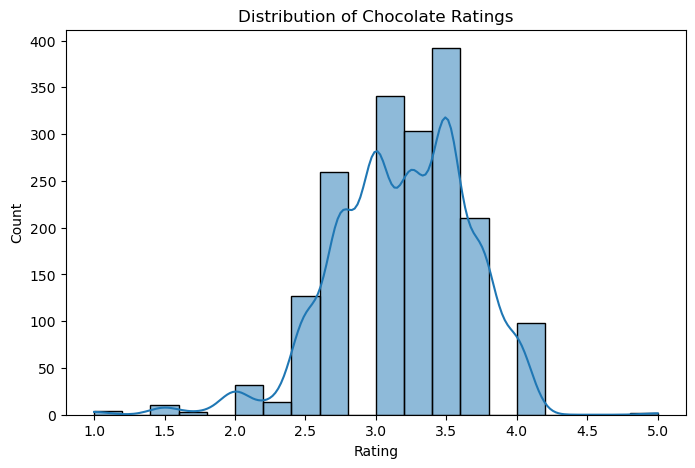

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Chocolate Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


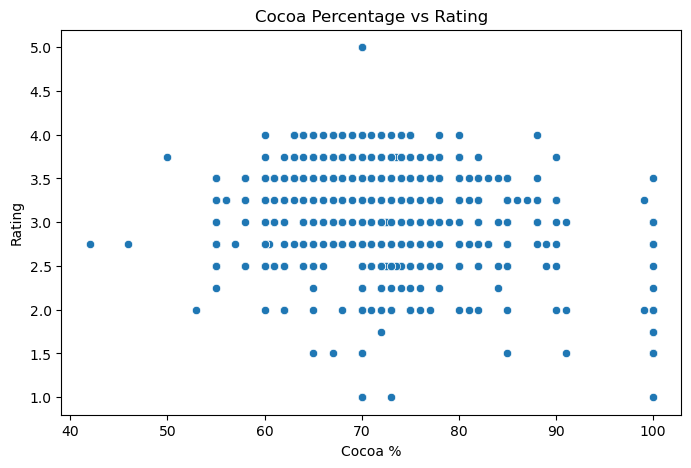

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='CocoaPercent', y='Rating', data=df)
plt.title('Cocoa Percentage vs Rating')
plt.xlabel('Cocoa %')
plt.ylabel('Rating')
plt.show()


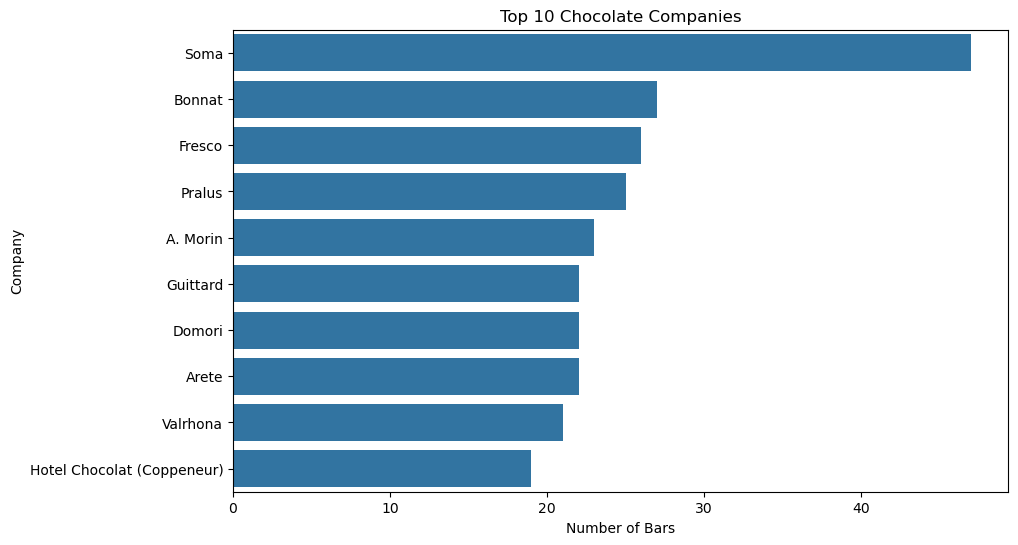

In [25]:
top_companies = df['Company'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title('Top 10 Chocolate Companies')
plt.xlabel('Number of Bars')
plt.ylabel('Company')
plt.show()


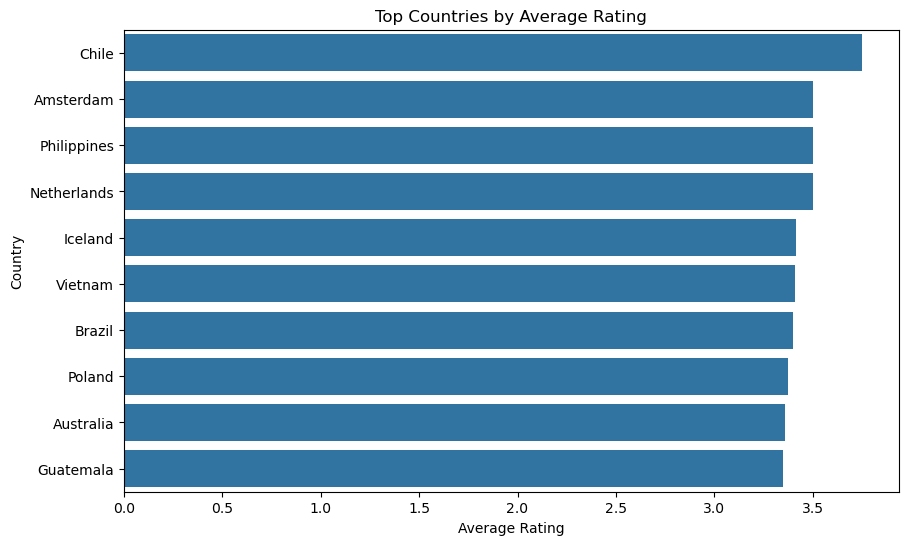

In [26]:
avg_country_rating = (
    df.groupby('CompanyLocation')['Rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_country_rating.values, y=avg_country_rating.index)
plt.title('Top Countries by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Country')
plt.show()


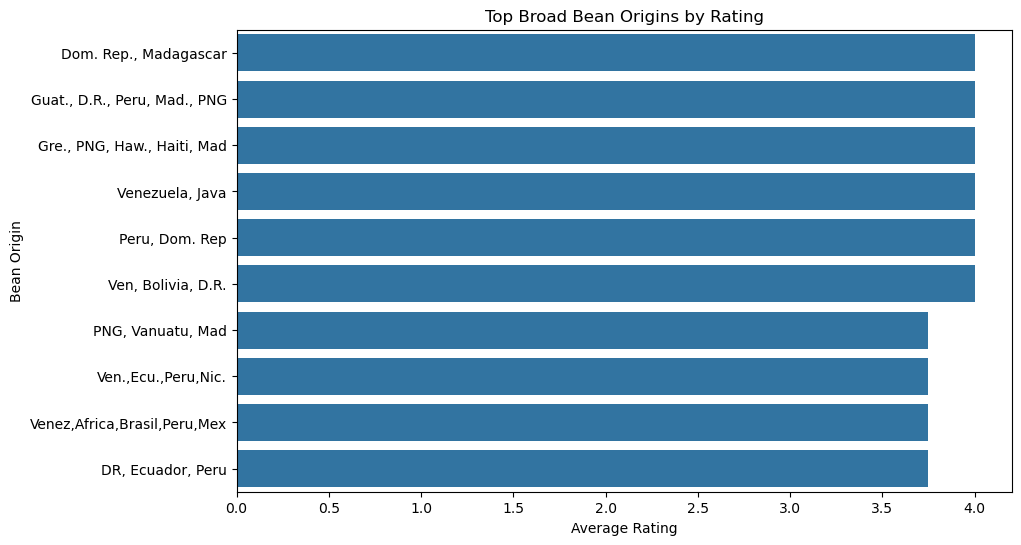

In [27]:
avg_origin_rating = (
    df.groupby('BroadBeanOrigin')['Rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_origin_rating.values, y=avg_origin_rating.index)
plt.title('Top Broad Bean Origins by Rating')
plt.xlabel('Average Rating')
plt.ylabel('Bean Origin')
plt.show()


In [28]:
df['BeanType'].fillna('Unknown', inplace=True)
df['BroadBeanOrigin'].fillna('Unknown', inplace=True)


C:\Users\VIHASHINI\AppData\Local\Temp\ipykernel_20420\4154738536.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BeanType'].fillna('Unknown', inplace=True)
C:\Users\VIHASHINI\AppData\Local\Temp\ipykernel_20420\4154738536.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [29]:
from sklearn.preprocessing import LabelEncoder

le_company = LabelEncoder()
le_origin = LabelEncoder()
le_bean = LabelEncoder()
le_country = LabelEncoder()

df['Company_Label'] = le_company.fit_transform(df['Company'])
df['Origin_Label'] = le_origin.fit_transform(df['BroadBeanOrigin'])
df['Bean_Label'] = le_bean.fit_transform(df['BeanType'])
df['Country_Label'] = le_country.fit_transform(df['CompanyLocation'])


In [73]:
from sklearn.model_selection import train_test_split

X = df.drop('Rating', axis=1)
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [74]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()


In [75]:
from sklearn.impute import SimpleImputer

# Numerical imputer
num_imputer = SimpleImputer(strategy='median')

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])


In [76]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])


In [77]:
print(X_train.dtypes)
print(X_test.dtypes)


Company            float64
BeanOrigin         float64
REF                float64
ReviewDate         float64
CocoaPercent       float64
CompanyLocation    float64
BeanType           float64
BroadBeanOrigin    float64
Company_Label      float64
Origin_Label       float64
Bean_Label         float64
Country_Label      float64
dtype: object
Company            float64
BeanOrigin         float64
REF                float64
ReviewDate         float64
CocoaPercent       float64
CompanyLocation    float64
BeanType           float64
BroadBeanOrigin    float64
Company_Label      float64
Origin_Label       float64
Bean_Label         float64
Country_Label      float64
dtype: object


In [82]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

model.fit(X_train, y_train)


ExtraTreesRegressor(max_depth=20, min_samples_leaf=2, n_estimators=500,
                    n_jobs=-1, random_state=42)

In [84]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")
print(f"Accuracy (%): {r2 * 100}")


RMSE: 0.4316376959726826
R² Score: 0.19402665253185858
Accuracy (%): 19.40266525318586
